# Machine Learning for Real Estate Business Applications

### by Margaret Bowers

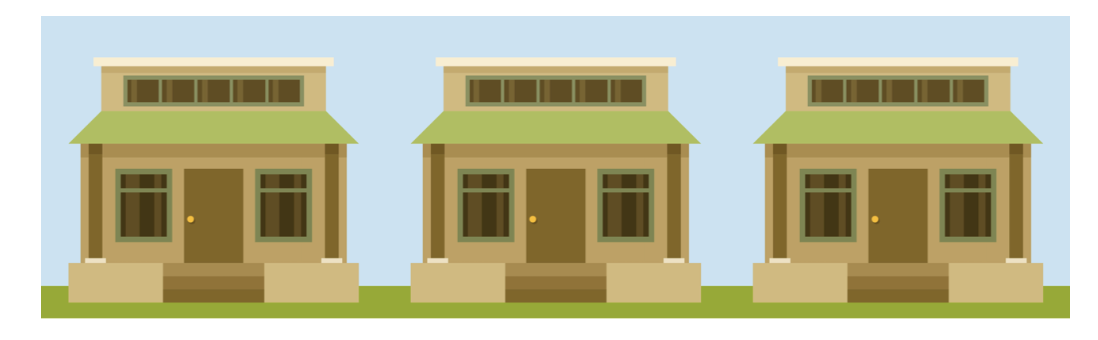

In [3]:
#| echo: false
from IPython.display import display, Image
Image('images/Header.png')

*Illustrations by [Public domain vectors](https://unsplash.com/@publicdomainvectors/illustrations) on [Unsplash](https://unsplash.com/illustrations/heres-a-possible-caption-a-cartoon-house-is-displayed-on-the-green-grass-f_lYPwzA_k0?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash)*

Machine Learning is a powerful tool for understanding data. But how do we choose the ‘best’ model and who should use it? I explored this question using the Ames Iowa real estate dataset, training a series of linear and tree models to gain insight into which algorithms were best suited for different business applications. 

## Data

The Ames dataset, created by Dean de Cock, represents the kind of real estate data that a home buyer or real estate agent might use to understand and predict property values. 
The dataset I used was slightly smaller than de Cock’s, consisting of 2580 observations and 79 features (not including the target, SalePrice). Using his data dictionary as a guide, I ended up with 48 categorical and 31 numerical features. 

My data analysis included analysing outliers, datatypes, and data imputation. I investigated feature engineering, transformations, feature selection, and multicollinearity and evaluated my tuned and optimized models based on overall performance, model consistency, and model reliability.

## Data Imputation

Twenty-seven features had missing data, 6 of which were missing more than half their data. Many properties had missing values because they lacked the particular structural elements named for those values.

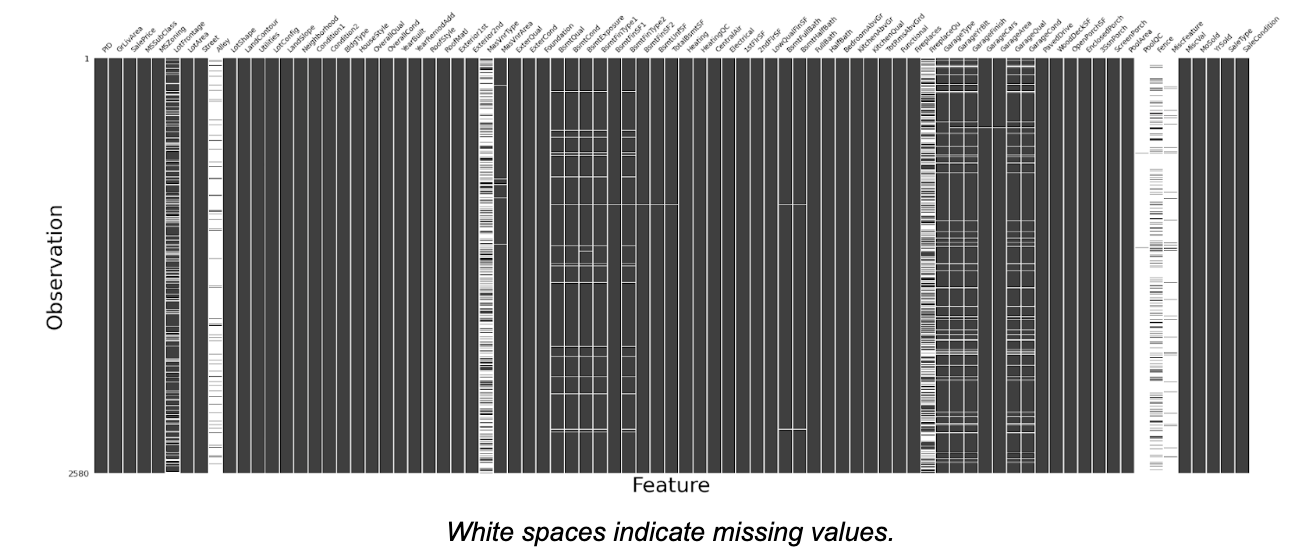

In [8]:
#| echo: false
Image('images/Missing_Values.png')

For my categorical features, I imputed a single missing Electrical feature with its mode and the rest with ‘None’. I imputed my missing numerical features with median values except for GarageYrBlt. During my EDA, I discovered that GarageYrBlt and YearBuilt were highly correlated. Accordingly, I used the  value of YearBuilt where it was missing for GarageYrblt, avoiding the introduction of added bias through my imputation method. 

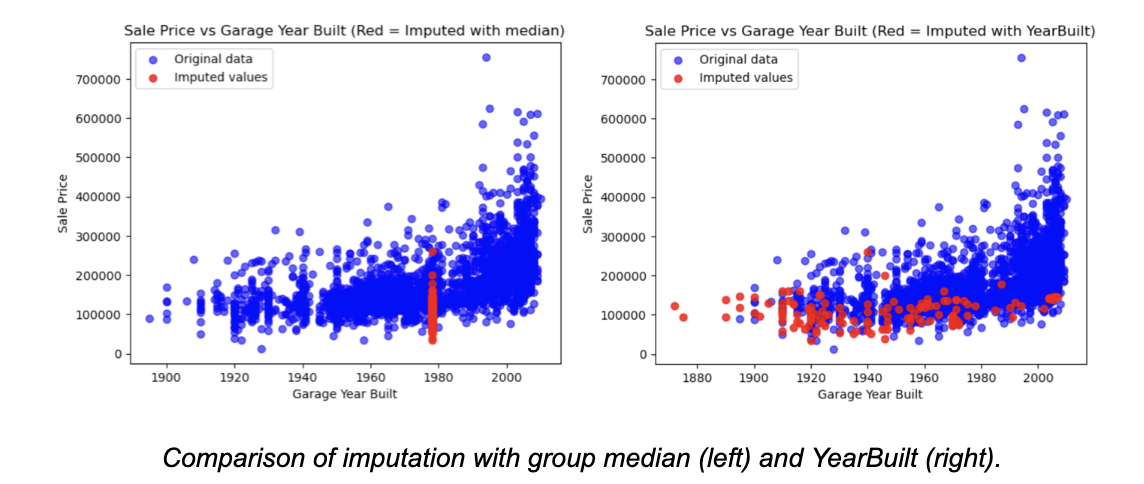

In [11]:
#| echo: false
Image('images/Imputation_Comparison.png')

## Outliers

De Cock’s data dictionary mentions 5 GrLivArea outliers that he recommends removing. Because my dataset was smaller, I only identified 2 with square footage values in excess of 4000 square feet. These 2 data points account for a difference in performance of 0.2%. I also investigated feature variances, discovering more than 100 extreme outliers falling more than 5 standard deviations outside their mean. In the interest of preserving data and making models robust to outliers, I chose not to remove any, including the 2 large square footage observations. 

## Log Transformations

Another step in my EDA was to examine numerical feature skew values to see how transformations might impact performance, analyzing feature and target transformation separately. After log transforming 5 of the 6 most highly skewed features, model performance improved by 0.3%. Log transforming the target alone had a much bigger impact, improving model performance by several percentage points. For the sake of simplicity, I transformed the target and compared linear-linear and log-linear models.

## Multicollinearity and Feature Reduction

There were 2 groups of highly multicollinear area features that I analyzed. 

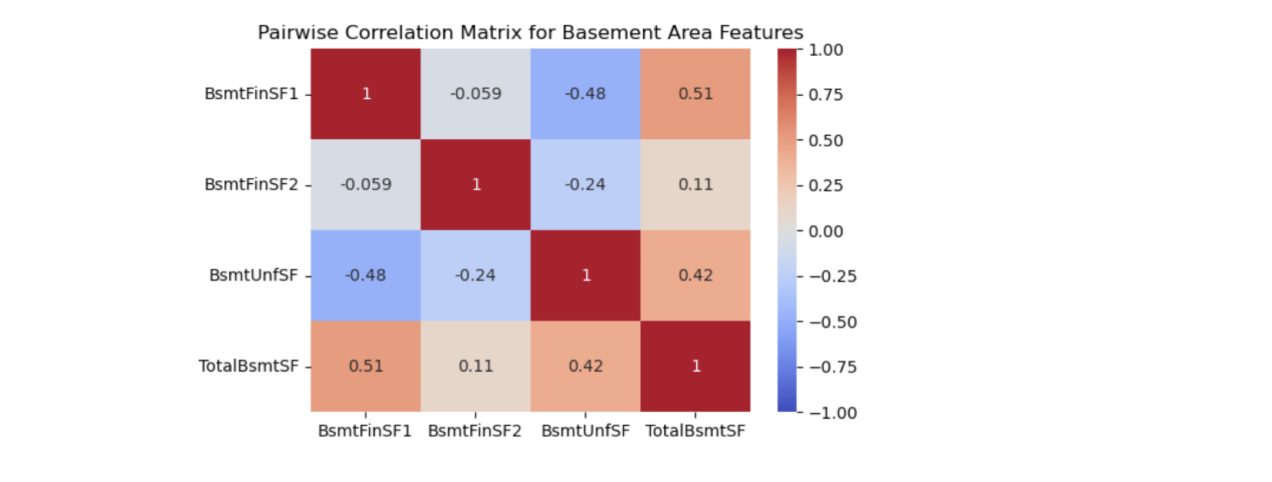

In [14]:
#| echo: false
Image('images/Heatmap.png')

These consisted of composite features (total areas) and component features (subsets of areas). I relied on scikit-learn’s SequentialFeatureSelector for feature reduction to resolve issues of multicollinearity and to capture feature interactions.

It was interesting to see how the penalized models captured feature interactions, retaining the composite area features, as well as significant component area features. 

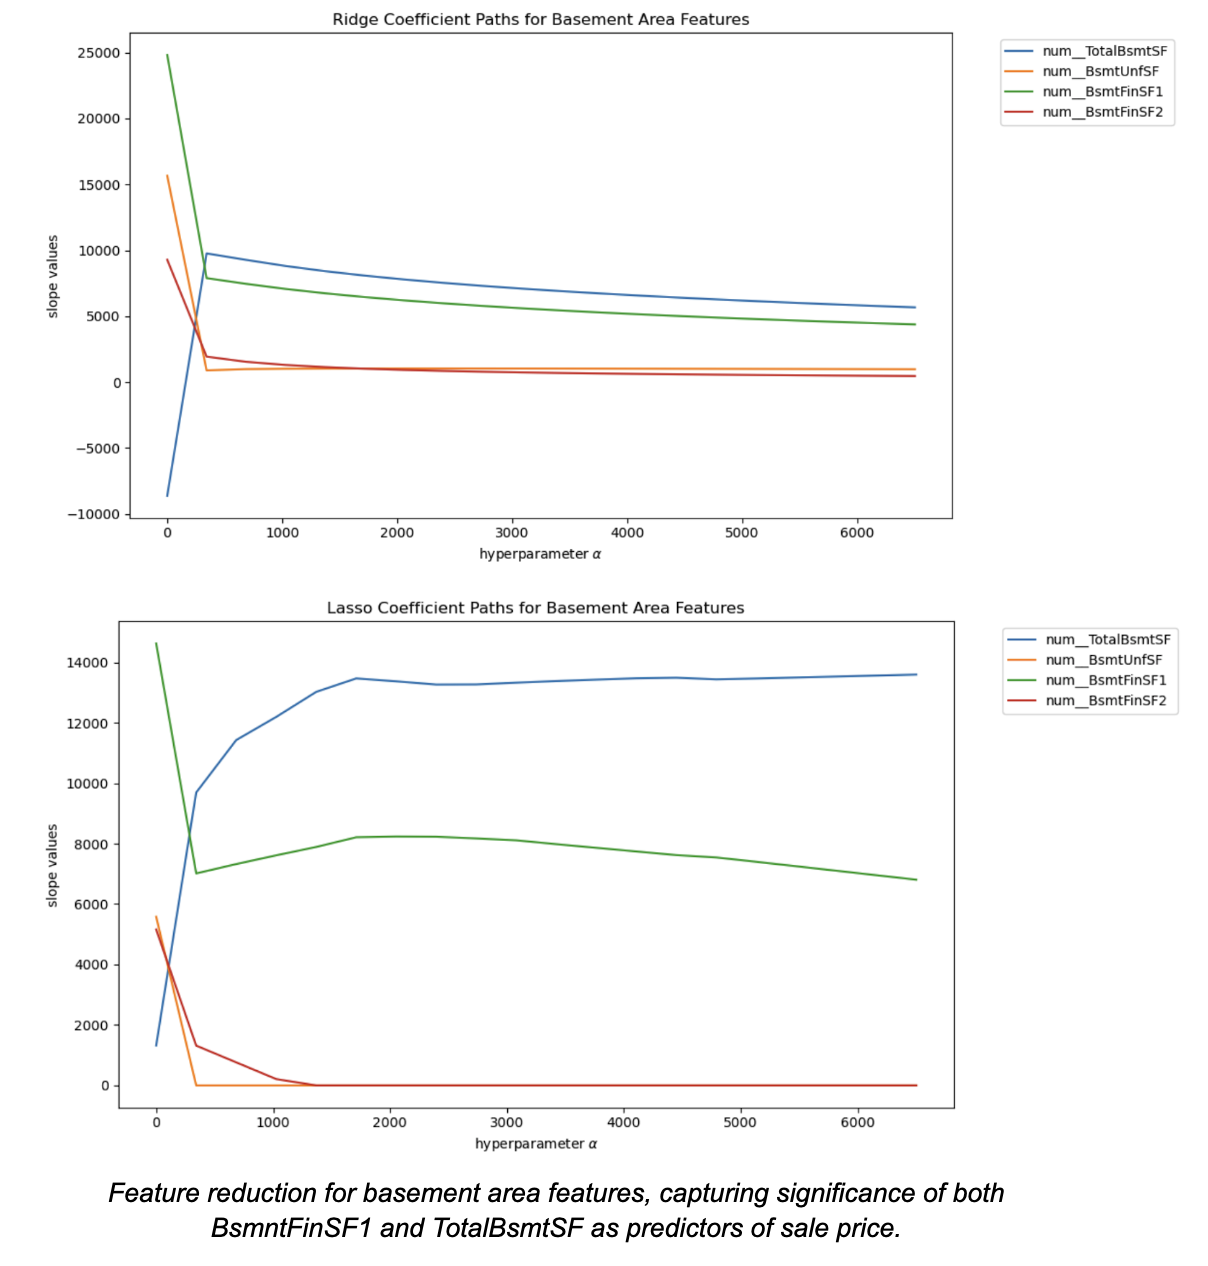

In [16]:
#| echo: false
Image('images/Coefficient_Paths.png')

Not surprisingly, using SequentialFeatureSelector (sfs) for the penalized models did not improve model performance, since these algorithms are optimized to do that on their own.  

I reduced my categorical features manually for my linear models by comparing model performance for different subsets of categorical features in combination with my sfs-reduced numerical features. 

## Models

For each algorithm, I trained a base model with all the features and default parameters, and then applied tuning and feature engineering as needed. The models I trained were not exhaustive and are the accumulation of my experimentation. While I always aimed for the highest score, I was interested in understanding model behavior throughout the process of tuning and feature engineering. 

For my linear algorithms, I trained MLR, Ridge, Lasso, and ElasticNet models on my imputed data, using GridSeachCV for hyperparameter tuning. 

For my tree algorithms, I trained RandomForest, GradientBoosting, XGBoost and CatBoost models. I used my imputed data, except for one Catboost model and one XGBoost model to see how their built-in imputation methods handled missing values.

Tuning had a significant impact on performance. My highest scoring XGBoost benefitted from increasing the number of estimators. The highest performing CatBoost model was the base model trained on the raw data without any tuning. GradientBoosting models benefitted from using RandomizedSearchCV to choose the parameter ranges. And RandomForest performance scores improved as the number of estimators grew.

## Performance Metrics

For each model, I used cross-validation as my scoring metric and collected the following data:

- **mean-cv:** this is a measure of how well the model explains the full dataset. This is the metric I chose to compare models to one another and to evaluate model accuracy. 
- **train and test scores:** using a train test split of 80/20, these scores measure how well a model performs on unseen data, or model generalization.
- **train-test gap:** this is the difference between how well a model performs on data it was trained on and how well the model performs on unseen data. That is an essential metric for understanding issues of overfitting.

The behavior of different algorithms to tuning and feature engineering can be seen below:

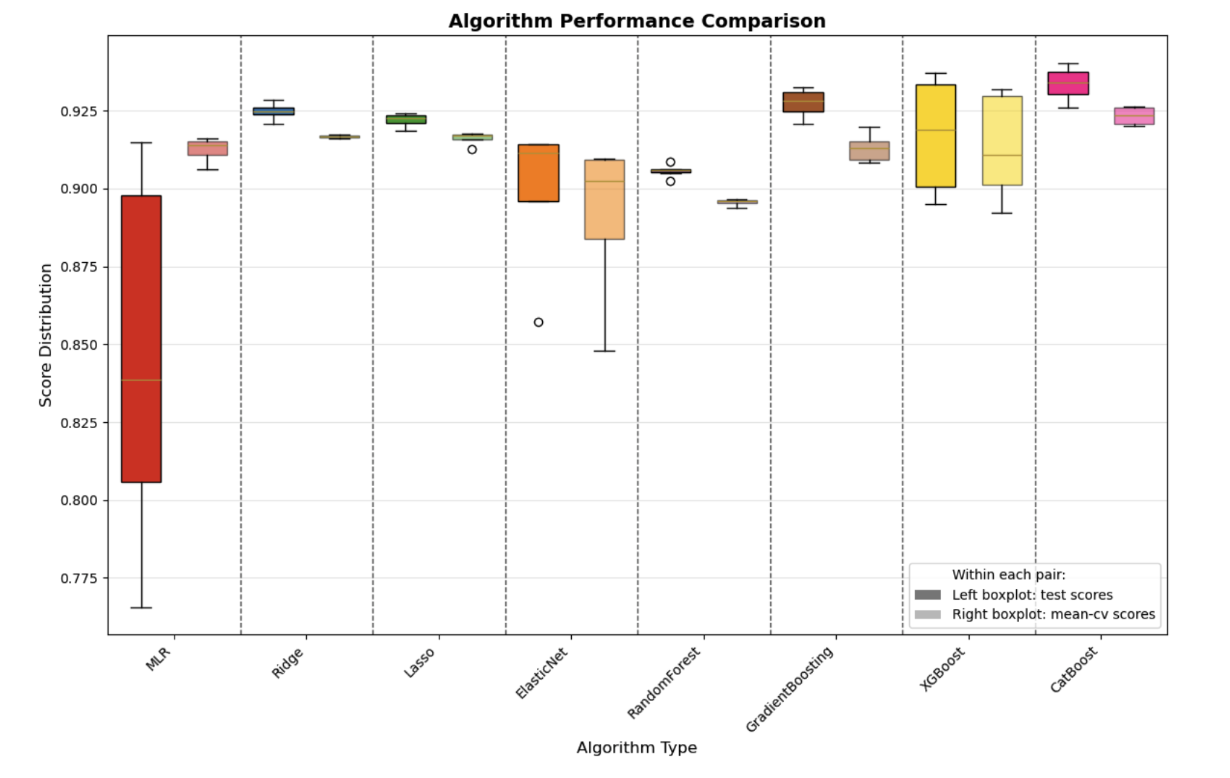

In [20]:
#| echo: false
Image('images/Algorithm_Performance_Comparison.png')

For the MLR models, mean-cv scores (right boxplot) are fairly consistent, but performance on unseen data (left boxplot) is more unreliable, due to the algorithm’s sensitivity to tuning and feature engineering. Ridge and Lasso are more consistent but are not the strongest performers. ElasticNet and XGBoost also showed more sensitivity to tuning. RandomForest did not perform well. 

Combining metrics for overall performance (mean-cv) and the train-test difference reveals additional characteristics about each algorithm.

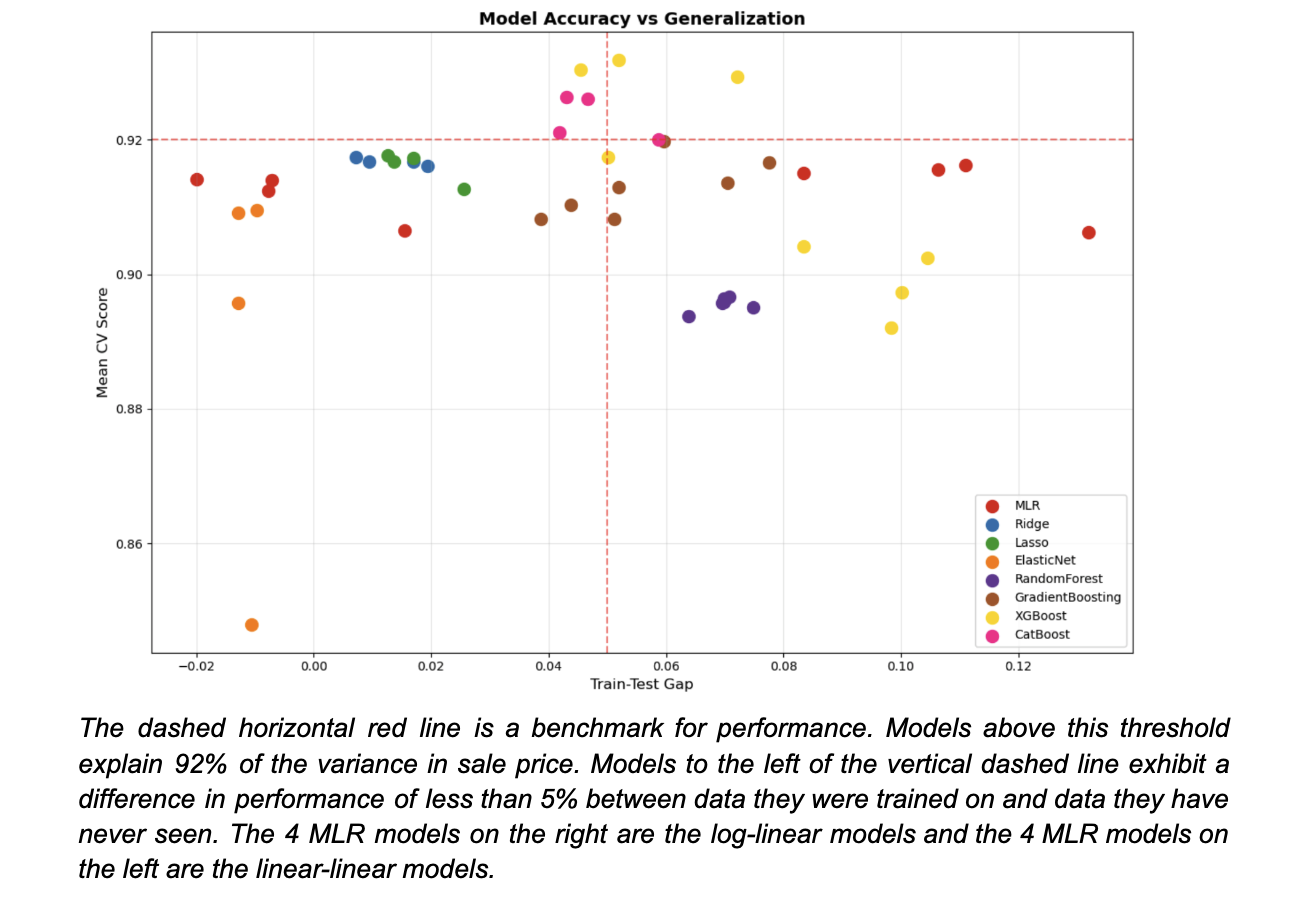

In [23]:
#| echo: false
Image('images/Model_Accuracy_vs_Generalization.png')

While the mean-cv score is the most important metric for model comparison, the train-test gap reveals how well an algorithm generalizes to unseen data. For example, the MLR model on the far right (within the family of log-linear models) is very overfitted and will perform 13% worse on data it has never seen as a result. 

## Business Recommendations

What model should we use? It depends on who is asking and what they intend to use it for. There are many different interests in the field of real estate that include real estate agents, investors, developers, and homeowners. 

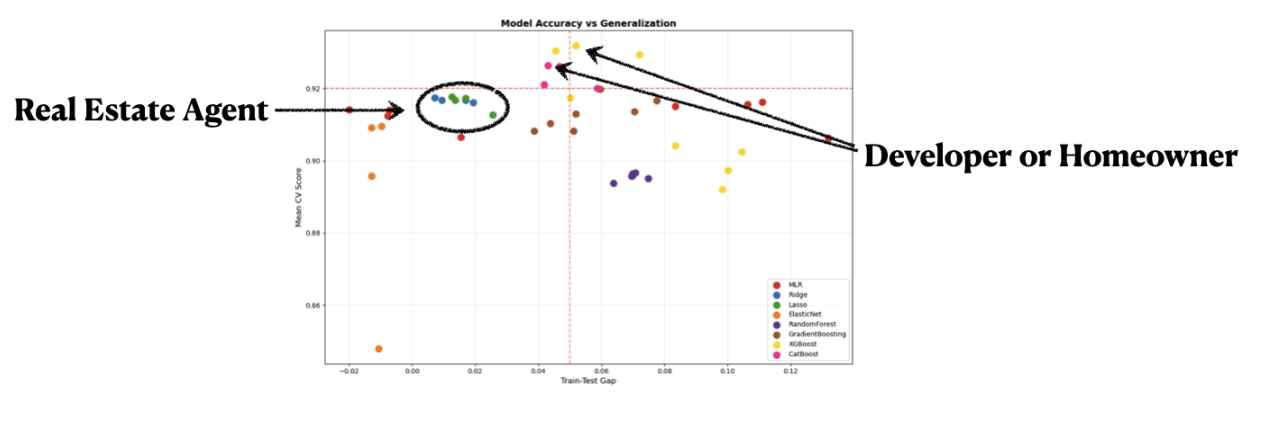

In [26]:
#| echo: false
Image('images/Model_Accuracy_vs_Generalization2.png')

The most accurate models are the XGBoost and CatBoost models, explaining as much as 93% of the variance in sale price.

The strengths of these models include their ease for deciphering feature importance, but proper tuning can take time. The highest performing CatBoost model was trained on raw data. If precision is essential, and there is not a lot of time to tune models or handle missing data, the best choice would be CatBoost. While it is not as accurate as XGBoost, it does offer  a good starting point. 

Because these models allow for easy investigation, I would recommend them for real estate developers who want to know how specific features impact sale price. For instance, they would be interested to learn if a fireplace or a finished basement would add more value to the price than it costs to include. I would also recommend these models to help homeowners understand remodeling efforts, such as how transforming a garage into a kitchen might impact their investment.

A real estate agent might want a fast, general understanding of market values and might not have time to wait for careful tuning. Ridge and Lasso are consistent and fast and would provide a general understanding of a market that can change quickly.

What about investors? The best performing models are performing at just over 93%. A 7% error is a big risk, which means that these models may not be reliable enough for their purposes.  Before investing in better tuning and feature engineering, it would be well advised to consider other algorithms.

## Conclusions and Future Work

Optimizing models for the best performance is always the goal with any machine learning project, but there are business applications where these top performers might not be the most appropriate. Understanding model behavior helps guide these choices.  

This project provided so many opportunities for investigation, including exploring different approaches for defining and handling outliers. As a real-world application, removing outliers would make algorithms less robust to properties with oversized homes but could improve accuracy. Depending on market trends, this may or may not be advisable. It would be interesting to apply this analysis to local data, have conversations with real estate experts in my community, and see what I could discover about the real estate market in Spokane.
